In [2]:
from sklearn import (
    linear_model,
    svm,
    neural_network as nn,

)
import mujoco
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib_tufte import *
setup()

In [3]:
def plot_wind_estimation(y, y_pred, smooth=True, window_size=50):    
    fig, ax = plt.subplots(figsize=(18, 4), dpi=100)
    steps = np.arange(len(y))
    ax.plot(steps, y, alpha=0.3, label="true wind angle (°)")
    ax.plot(steps, np.convolve(y_pred, np.ones(window_size)/window_size, mode='same'), label="estimated angle")
    ax.set_xlabel("Step")
    ax.set_ylabel("Wind angle (°)")
    ax.legend()
    plt.show()

In [4]:
fit_models = {}

In [5]:
SEEDS_FIXED   = [1, 67, 777, 42]
N_STEPS = 20000
N_SEEDS = 15

In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

from tqdm import trange
from flygym.compose import ActuatorType
from miniproject.simulation import MiniprojectSimulation
from submission.controller import Controller
from submission.config import load_config


seeds_random = np.random.RandomState(42).choice(1000, size=N_SEEDS - len(SEEDS_FIXED), replace=False)
print(f"Using seeds: {SEEDS_FIXED + seeds_random.tolist()}")

CONFIG_PATH = Path("..") / "submission/config/stable_config.yaml"
config = load_config(CONFIG_PATH)

# Accumulated across all seeds
all_wind_direction  = []
all_fly_thorax_quat = []
all_qpos_history    = []

for seed in SEEDS_FIXED+seeds_random.tolist():
    sim          = MiniprojectSimulation(level=3, seed=seed)
    controller   = Controller(sim, config)
    thorax_id    = mujoco.mj_name2id(
        sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, f"{sim.fly.name}/c_thorax"
    )

    for _ in trange(N_STEPS, desc=f"seed={seed}"):
        joint_angles, adhesion = controller.step(sim)
        all_wind_direction.append(sim.mj_model.opt.wind[:2].copy())
        all_fly_thorax_quat.append(sim.mj_data.xquat[thorax_id].copy())
        antenna_data = sim.get_antenna_data(sim.fly.name)
        all_qpos_history.append({
            "q_lx": antenna_data["l"]["qpos"][1],
            "q_ly": antenna_data["l"]["qpos"][2],
            "q_lz": antenna_data["l"]["qpos"][3],
            "q_rx": antenna_data["r"]["qpos"][1],
            "q_ry": antenna_data["r"]["qpos"][2],
            "q_rz": antenna_data["r"]["qpos"][3],
        })
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(sim.fly.name, ActuatorType.ADHESION, adhesion)
        sim.step()
        sim.render_as_needed()

print(f"Collected {len(all_wind_direction):,} steps across {N_SEEDS} seeds")


In [6]:
# X = pd.DataFrame(all_qpos_history)
# y = np.arctan2(
#     [wd[1] for wd in all_wind_direction],  # wind_y
#     [wd[0] for wd in all_wind_direction],  # wind_x
# )

# X.to_csv("X.csv", index=False)
# np.savetxt("y.csv", y, delimiter=",")

X = pd.read_csv("X.csv")
y = np.loadtxt("y.csv", delimiter=",")

N_samples = 50000
X = X.iloc[:N_samples]
y = y[:N_samples]

train_split = int(len(X) * 0.8)

X_train, y_train = X.iloc[train_split:], y[train_split:]
X_test, y_test   = X.iloc[:train_split], y[:train_split]

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

Training set: 10,000 samples
Test set: 40,000 samples


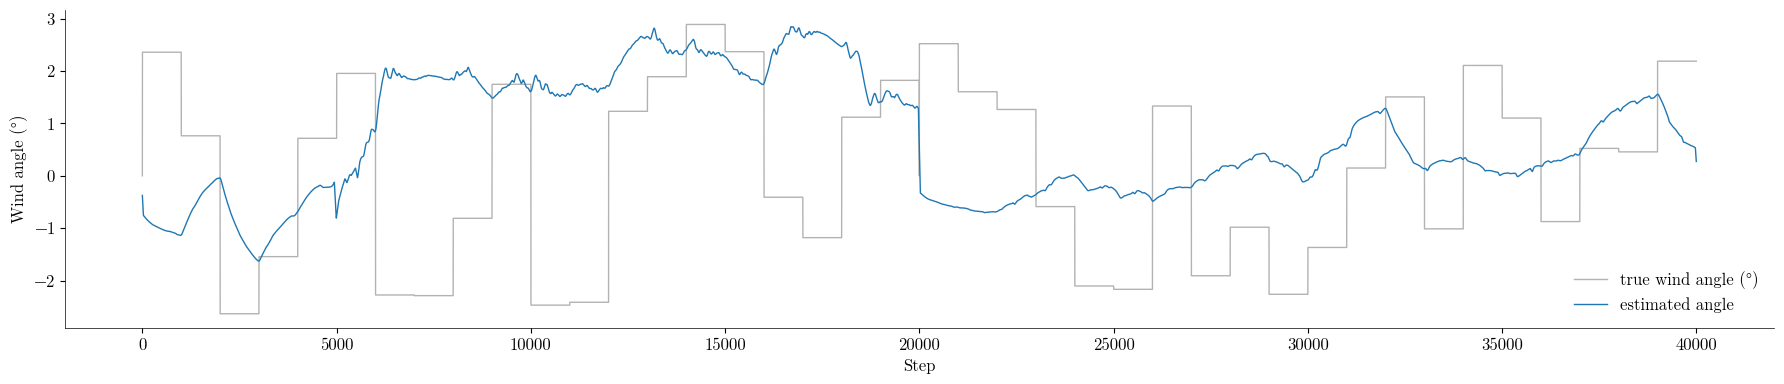

In [7]:
# Ridge regression
# —— Parameters for Ridge regression ——————
alpha = 0.0001  # Regularization strength
# —————————————————————————————————————————

clf = linear_model.Ridge(alpha=alpha)
clf.fit(X_train, y_train)
fit_models["Ridge"] = clf

y_pred = clf.predict(X_test)
plot_wind_estimation(y_test[:], y_pred[:])

Training SVR (kernel=rbf, C=1.0, ε=0.1)
  X_train: (10000, 4),  y_train: (10000,)
[1/3] Fitting...
[LibSVM].....
*
optimization finished, #iter = 5580
obj = -6077.029587, rho = -2.267327
nSV = 6484, nBSV = 6465
[2/3] Fit done in 0.9s — 6484 support vectors
[3/3] Prediction done in 7.2s


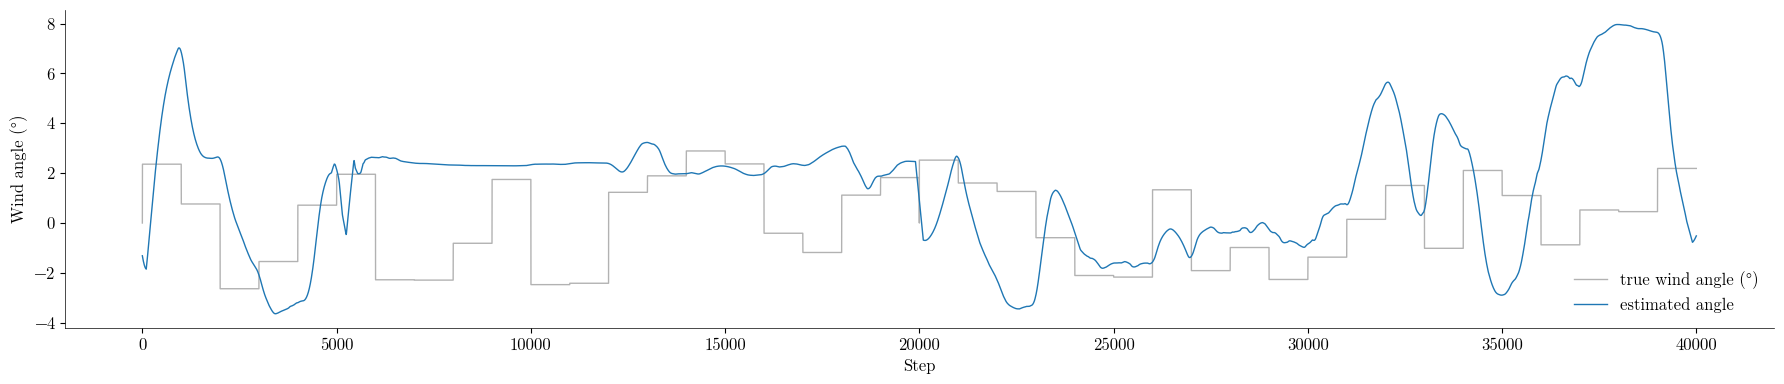

In [8]:
import time

# Support Vector regression
# —— Parameters for SVR ——————
# kernel = 'linear'  # Linear kernel
# kernel = 'poly'    # Polynomial kernel
kernel = 'rbf'     # Radial basis function kernel
C = 1.0          # Regularization parameter
epsilon = 0.1    # Epsilon for the epsilon-SVR
# ————————————————————————————

print(f"Training SVR (kernel={kernel}, C={C}, ε={epsilon})")
print(f"  X_train: {X_train.shape},  y_train: {y_train.shape}")

clf = svm.SVR(kernel=kernel, C=C, epsilon=epsilon, verbose=True)

t0 = time.time()
print("[1/3] Fitting...")
clf.fit(X_train, y_train)
print(f"[2/3] Fit done in {time.time() - t0:.1f}s — {clf.n_support_[0]} support vectors")

t1 = time.time()
y_pred = clf.predict(X_test)
print(f"[3/3] Prediction done in {time.time() - t1:.1f}s")

fit_models[f"SVR ({kernel})"] = clf
plot_wind_estimation(y_test, y_pred, smooth=True, window_size=200)


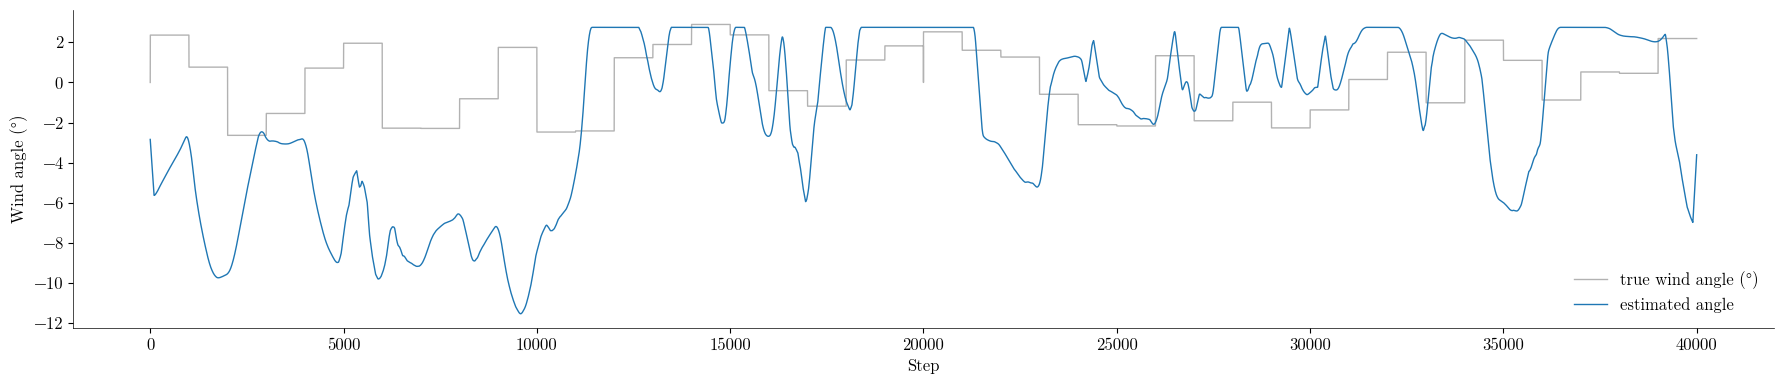

In [12]:
# Neural network
# —— Parameters for MLPRegressor ——————
hidden_layer_sizes = (100, 50, 1000, 3, 100, 4)  # Two hidden layers with 100 and
activation = 'relu'  # Activation function
# —————————————————————————————————————————

clf = nn.MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, activation=activation, max_iter=5000)
clf.fit(X_train, y_train)
fit_models[f"MLPRegressor (hidden={hidden_layer_sizes}, activation={activation})"] = clf
y_pred = clf.predict(X_test)
plot_wind_estimation(y_test, y_pred, smooth=True, window_size=200)

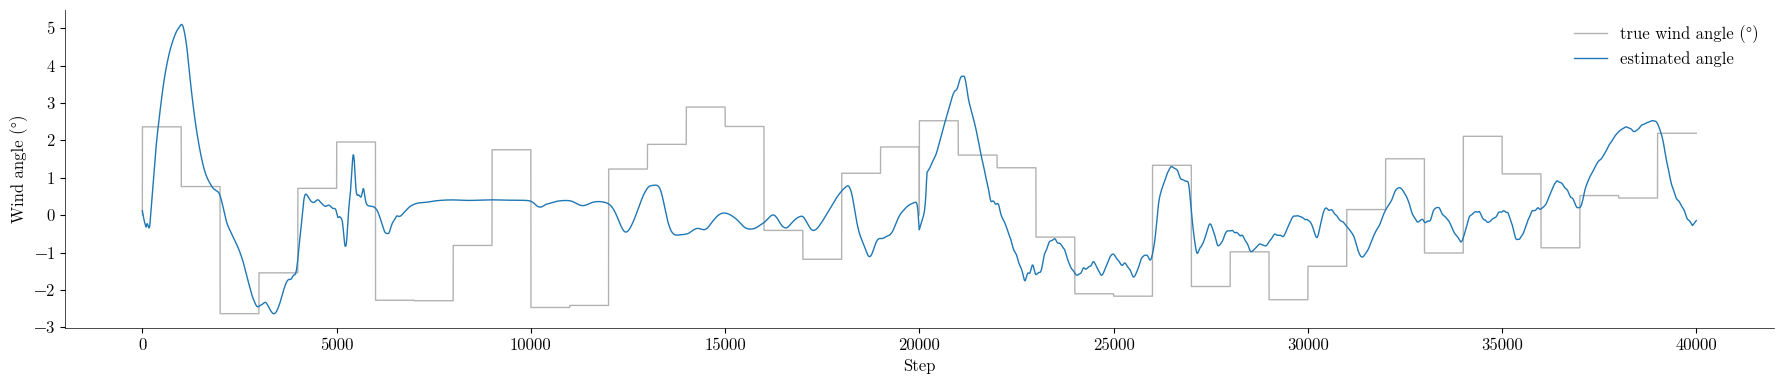

In [10]:
# Temporal SVR
# —— Parameters for Temporal SVR ——————
memory = 100

# —————————————————————————————————————

X_train_temporal = np.hstack([X_train.shift(i).fillna(0) for i in range(memory)])
X_test_temporal = np.hstack([X_test.shift(i).fillna(0) for i in range(memory)])
clf = svm.SVR(kernel='rbf')
clf.fit(X_train_temporal, y_train)
fit_models[f"Temporal SVR (memory={memory})"] = clf
y_pred = clf.predict(X_test_temporal)
plot_wind_estimation(y_test, y_pred, smooth=True, window_size=200)
